# 01b some summary stats
Bur oak common garden genomics  
ahipp@mortonarb.org, 2024-09-24  

## Running this notebook
see `01.dataProcessingBash` for details. Make sure you run this notebook in the `garden` conda environment. As a reminder, here's the folder structure:

In [2]:
system2("tree", args = c('../', '-d'), stdout = T) |> print()

 [1] "../"                                    
 [2] "├── condaEnv"                           
 [3] "├── data"                               
 [4] "│   ├── bed"                            
 [5] "│   ├── KHUFU"                          
 [6] "│   └── little-maps"                    
 [7] "│       ├── originals"                  
 [8] "│       │   ├── alba_litt802av"         
 [9] "│       │   ├── bicolor_litt804av"      
[10] "│       │   ├── macrocarpa_litt823av"   
[11] "│       │   ├── muehlenbergii_litt826av"
[12] "│       │   └── stellata_litt835av"     
[13] "│       └── shapefiles"                 
[14] "├── out"                                
[15] "│   ├── admixture"                      
[16] "│   │   ├── imputed"                    
[17] "│   │   ├── imputed.m90"                
[18] "│   │   ├── raw"                        
[19] "│   │   └── raw.m90"                    
[20] "│   ├── admixture.plots"                
[21] "│   │   ├── imputed"                    
[22] "│   │  

## Read vcf data and plot chromosome coverage

In [8]:
stop(c("COMMENT OUT THIS LINE IF YOU REALLY NEED TO RUN AGAIN!!!",
       "\nThis cell takes time and isn't needed for anything else on the page.",
       "\n\n---------------------\n\n"),
     call. = FALSE
     )

library(vcfR)
library(ggplot2)

message('... reading data...')
dat.vcf <- list(
    raw = read.vcfR('../data/KHUFU/KHU075_SNPcalls_20241105.raw.vcf.gz') |> vcfR2tidy(),
    imputed = read.vcfR('../data/KHUFU/KHU075_SNPcalls_20241105.imputed.vcf.gz') |> vcfR2tidy()
    )

message('... plotting data...')
for(i in names(dat.vcf)) {
    temp <- dat.vcf[[i]]$fix
    names(temp)[2:3] <- c('Chromosome', 'Position')
    temp$Chromosome <- gsub('OM.SCF', 'C', temp$Chromosome, fixed = T)
    out <- ggplot(temp, aes(x = Chromosome, y = Position))
    out <- out + geom_point(color = 'black', alpha = 0.005, pch = '-', size = 6)
    print(out)
    ggsave(paste0('../out/khufu.chromo.', i, '.pdf'))
    }

ERROR: Error: COMMENT OUT THIS LINE IF YOU REALLY NEED TO RUN AGAIN!!!
This cell takes time and isn't needed for anything else on the page

---------------------




## create data table

In [1]:
### read this back in in 01d
library(openxlsx)

# dat.orig <- read.xlsx('../data/OakSpmExtract-KhufuTips-20240513.xlsx')
dat <- read.csv('../data/OakSpmExtract-KhufuTips-20241114.csv', check.names = F)
# head(dat.orig)
# head(dat)
row.names(dat) <- dat$khufuTips
st <- state.abb; names(st) <- state.name
dat$stateAbb <- as.character(st[dat$'state_province_georef'])
dat$Qsp <- gsub('Quercus ', '', dat$'TAXA-Current_determination', fixed = T)

## clean up some nomenclatural problems and taxonomy errors in our raw data
replace <- list(
    from = c(
        "alba x michauxii Nutt.", 
        "durandii", 
        "lyrata (aff. Q. macrocarpa)", 
        "prinoides", 
        "stellata (margaretta?)"
        ),
    to = c(
        "michauxii",
        "sinuata",
        "lyrata",
        "muehlenbergii",
        "stellata"
        )
    )

datFields <- c("SPMCODE", "Collector_no", "MOTHER", "Collection_date", "Collectors", "Type_of_material", 
               "Country", "State_Province_Region_territory", "substate", "substateRank", "Site", "habitat", 
               "associates","livingCollectionsNumber", "OrigSourceInfo","latitude.orig", "longitude.orig",
               "MOR_Acc_Num", "latitude_georef", "longitude_georef", 
               "state_province_georef", "County_georef", "Site_georef", "City_georef",
               "khufuTips", "stateAbb", "motherSite", "Qsp")

for(i in seq_along(replace$from)) {
    dat$Qsp[which(dat$Qsp == replace$from[[i]])] <-
    replace$to[[i]]
}

## add states and sites
dat$motherState <- 
    sapply(
        strsplit(dat$MOTHER, '_', fixed = T),
        '[', 1
    )

dat$motherSite <- 
    sapply(
        lapply(
            strsplit(dat$MOTHER, '_', fixed = T),
        '[', 1:2),
        paste, collapse = '_' 
    )
dat$motherSite[dat$motherSite == 'NA_NA'] <- NA

dat$motherState <- ifelse(is.na(dat$motherState), '', dat$motherState)
dat$Qsp[!dat$motherState == ''] <-
    paste(dat$Qsp[!dat$motherState == ''], dat$motherState[!dat$motherState == ''], sep = '_')


write.csv(dat[datFields], '../out/oak.metadata.cleaned.csv')


## Summarize snp coverage
Already got the snp coverage data from vcf file, so let's go get it (still need to do this with bed files, but later... another day...

In [2]:
library(openxlsx)
library(stringr)

# read in the data submitted, and add a cleaned ID field
dat.submitted <- read.xlsx('../data/khufu_submitted_AHcleaned.xlsx')
dat.submitted <- dat.submitted[!is.na(dat.submitted$sampleID), ]
dat.submitted <- dat.submitted[dat.submitted$sampleID != 'Neg Control', ]
dat.submitted$cleanID <- gsub('-', '.', dat.submitted$sampleID, fixed = T)
index = grep('OAK|SYST', dat.submitted$cleanID, invert = T)

dat.submitted$cleanID[index] <- 
    paste('MOR',
          str_pad(gsub('MOR', '', dat.submitted$cleanID[index]), 4, pad = "0"),
          sep = ''
          )

row.names(dat.submitted) <- dat.submitted$cleanID
write.csv(dat.submitted, '../out/khufu_submitted_reformatted.csv')
dat.meta <- read.csv('../out/oak.metadata.cleaned.csv', row.names = 1)

if('vcf.stats.raw.table.csv' %in% dir('../out') && 'vcf.stats.imputed.table.csv' %in% dir('../out')) {
    message('*** stats.raw and stats.imputed read from out directory; delete these files if you want to recalc')
    stats.raw <- read.csv('../out/vcf.stats.raw.table.csv', row.names = 1)
    stats.imputed <- read.csv('../out/vcf.stats.imputed.table.csv', row.names = 1)
    } else {

        # read in the data stats for snps we got back
        stats.raw <- read.delim('../out/stats.raw_vcf.txt', header = F, skip = 29)
        stats.imputed <- read.delim('../out/stats.imputed_vcf.txt', header = F, skip = 29)
        
        colnames(stats.raw) <- names(stats.imputed) <- readLines('../data/stats.header.txt')
        
        # strip final row and add row.names
        stats.raw <- stats.raw[stats.raw$id == 'FLT0',]
        stats.imputed <- stats.imputed[stats.imputed$id == 'FLT0',]
        row.names(stats.raw) <- stats.raw$sample
        row.names(stats.imputed) <- stats.imputed$sample
        
        # get the sample metadata processed in notebook 02, weld on useful fields
        stats.raw <- cbind(stats.raw, dat.meta[row.names(stats.raw), c('SPMCODE', 'Qsp', 'stateAbb', 'MOTHER')])
        stats.imputed <- cbind(stats.imputed, dat.meta[row.names(stats.imputed), c('SPMCODE', 'Qsp', 'stateAbb', 'MOTHER')])
        
        # calculate percent pass, percent het
        stats.raw$percentPass <- stats.raw$numGenotypesPass / (stats.raw$numGenotypesPass + stats.raw$numMissing)
        stats.raw$percentHet <- stats.raw$numHet / stats.raw$numGenotypesPass
        
        stats.imputed$percentPass <- stats.imputed$numGenotypesPass / (stats.imputed$numGenotypesPass + stats.imputed$numMissing)
        stats.imputed$percentHet <- stats.imputed$numHet / stats.imputed$numGenotypesPass
        
        ## save those tables:
        write.csv(stats.raw, '../out/vcf.stats.raw.table.csv')
        write.csv(stats.imputed, '../out/vcf.stats.imputed.table.csv')
    } # close generating stats

# names(stats.raw)
# names(stats.imputed)
# dim(stats.raw)
# names(dat.submitted)

stats.raw <- stats.raw[setdiff(names(stats.raw), c('SPMCODE', 'Qsp', 'stateAbb', 'MOTHER'))]

temp <- data.frame(row.names = setdiff(row.names(stats.raw), x=row.names(dat.submitted)),
                   id = 'FLT0', 
                   sample = setdiff(row.names(stats.raw), x=row.names(dat.submitted))
                   )
temp <- cbind(temp, matrix(NA, dim(temp)[1], length(setdiff(names(stats.raw), c('id', 'sample')))))
names(temp)[3:dim(temp)[2]] <- names(stats.raw)[3:dim(temp)[2]]

# head(temp)

stats.raw.all <- rbind(
    stats.raw,
    temp
    ) # close rbind

stats.raw.all$numMissing[is.na(stats.raw.all$numMissing)] <- 
    stats.raw$numGenotypesPass[1] + stats.raw$numMissing[1]

# create a faux stats.raw.all for everything submitted

stats.raw.all <- cbind(stats.raw.all, dat.meta[row.names(stats.raw.all), c('SPMCODE', 'Qsp', 'stateAbb', 'MOTHER')])
stats.raw.all$percentPass <- stats.raw.all$numGenotypesPass / (stats.raw.all$numGenotypesPass + stats.raw.all$numMissing)
stats.raw.all$percentHet <- stats.raw.all$numHet / stats.raw.all$numGenotypesPass

write.csv(stats.raw.all, '../out/stats.raw.all.csv')
write.csv(cbind(stats.raw.all, dat.meta[row.names(stats.raw.all), setdiff(names(dat.meta), names(stats.raw.all))]),
          '../out/TABLE.Sx.metaAndStats.csv')

message('CHECK BELOW TO MAKE SURE THESE MAKE SENSE')
message('stats.raw.all')
dim(stats.raw.all)

message('stats.raw')
dim(stats.raw)

message('stats.imputed')
dim(stats.imputed)

head(stats.raw.all)
tail(stats.raw.all)

*** stats.raw and stats.imputed read from out directory; delete these files if you want to recalc

CHECK BELOW TO MAKE SURE THESE MAKE SENSE

stats.raw.all



[1] 1200   21

stats.raw



[1] 950  17

stats.imputed



[1] 950  21

,id,sample,numGenotypesPass,numGenotypesNonref,numHomoRef,numHomoAlt,numHet,numHemi,numSNVs,numIndels,⋯,numMissing,num_ts,num_tv,ts_tv,percentPass,percentHet,SPMCODE,Qsp,stateAbb,MOTHER
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
OAK.MOR.000132,FLT0,OAK.MOR.000132,206633,72973,133660,11930,61043,0,72973,0,⋯,42479,58526,14447,4.05,0.8294783,0.2954175,QUE000295,gambelii,AZ,NA
OAK.MOR.000635,FLT0,OAK.MOR.000635,215154,81266,133888,9533,71733,0,81266,0,⋯,33958,65338,15928,4.10,0.8636838,0.3334031,QUE000134,gambelii,NA,NA
OAK.MOR.001245,FLT0,OAK.MOR.001245,211422,80358,131064,14391,65967,0,80358,0,⋯,37690,64438,15920,4.05,0.8487026,0.3120158,QUE001840,muehlenbergii,NA,NA
OAK.MOR.001369,FLT0,OAK.MOR.001369,201939,75640,126299,16579,59061,0,75640,0,⋯,47173,61193,14447,4.24,0.8106354,0.2924695,QUE001833,stellata,MO,NA
OAK.MOR.001370,FLT0,OAK.MOR.001370,244799,144567,100232,2043,142524,0,144567,0,⋯,4313,116372,28195,4.13,0.9826865,0.5822083,QUE001835,muehlenbergii,MO,NA
OAK.MOR.001372,FLT0,OAK.MOR.001372,213596,83214,130382,17499,65715,0,83214,0,⋯,35516,67233,15981,4.21,0.8574296,0.3076603,QUE001857,stellata,MO,NA


,id,sample,numGenotypesPass,numGenotypesNonref,numHomoRef,numHomoAlt,numHet,numHemi,numSNVs,numIndels,⋯,numMissing,num_ts,num_tv,ts_tv,percentPass,percentHet,SPMCODE,Qsp,stateAbb,MOTHER
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
MOR0944,FLT0,MOR0944,NA,NA,NA,NA,NA,NA,NA,NA,⋯,249112,NA,NA,NA,NA,NA,MOR944,macrocarpa_IL,IL,IL_LW_641
SYST.MOR.0007025,FLT0,SYST.MOR.0007025,NA,NA,NA,NA,NA,NA,NA,NA,⋯,249112,NA,NA,NA,NA,NA,QUE003788,muehlenbergii,NA,NA
SYST.MOR.0007051,FLT0,SYST.MOR.0007051,NA,NA,NA,NA,NA,NA,NA,NA,⋯,249112,NA,NA,NA,NA,NA,QUE003814,alba,NA,NA
SYST.MOR.0007237,FLT0,SYST.MOR.0007237,NA,NA,NA,NA,NA,NA,NA,NA,⋯,249112,NA,NA,NA,NA,NA,QUE004000,alba,OH,NA
SYST.MOR.0007257,FLT0,SYST.MOR.0007257,NA,NA,NA,NA,NA,NA,NA,NA,⋯,249112,NA,NA,NA,NA,NA,QUE004020,alba,MN,NA
OAK.MOR.001442,FLT0,OAK.MOR.001442,NA,NA,NA,NA,NA,NA,NA,NA,⋯,249112,NA,NA,NA,NA,NA,QUE002149,alba,NA,NA


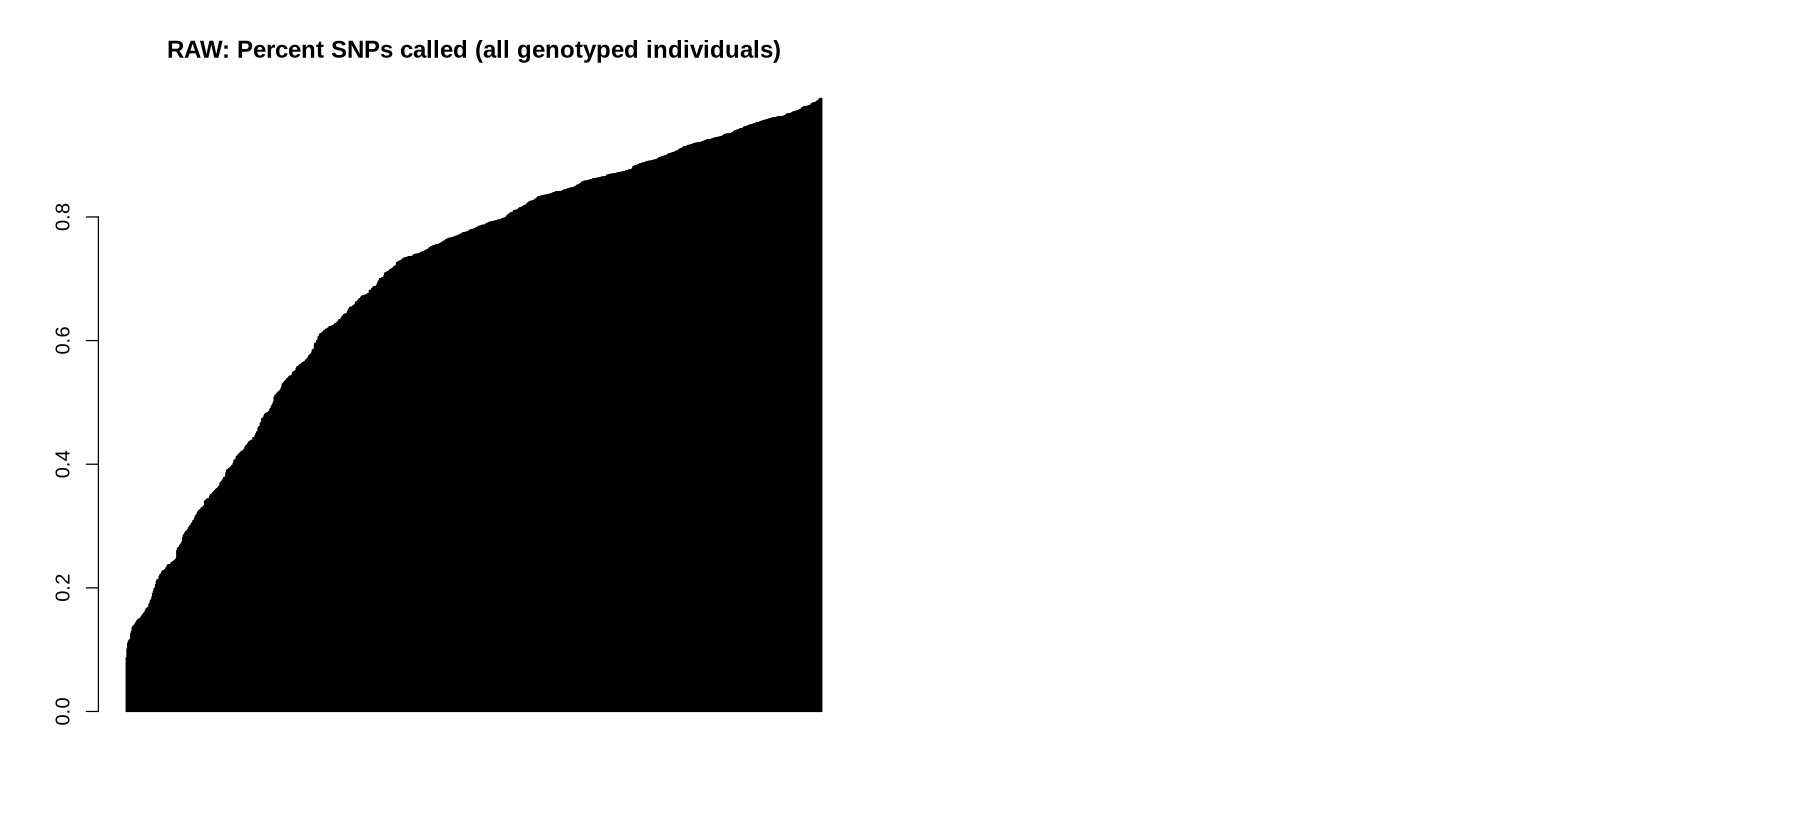

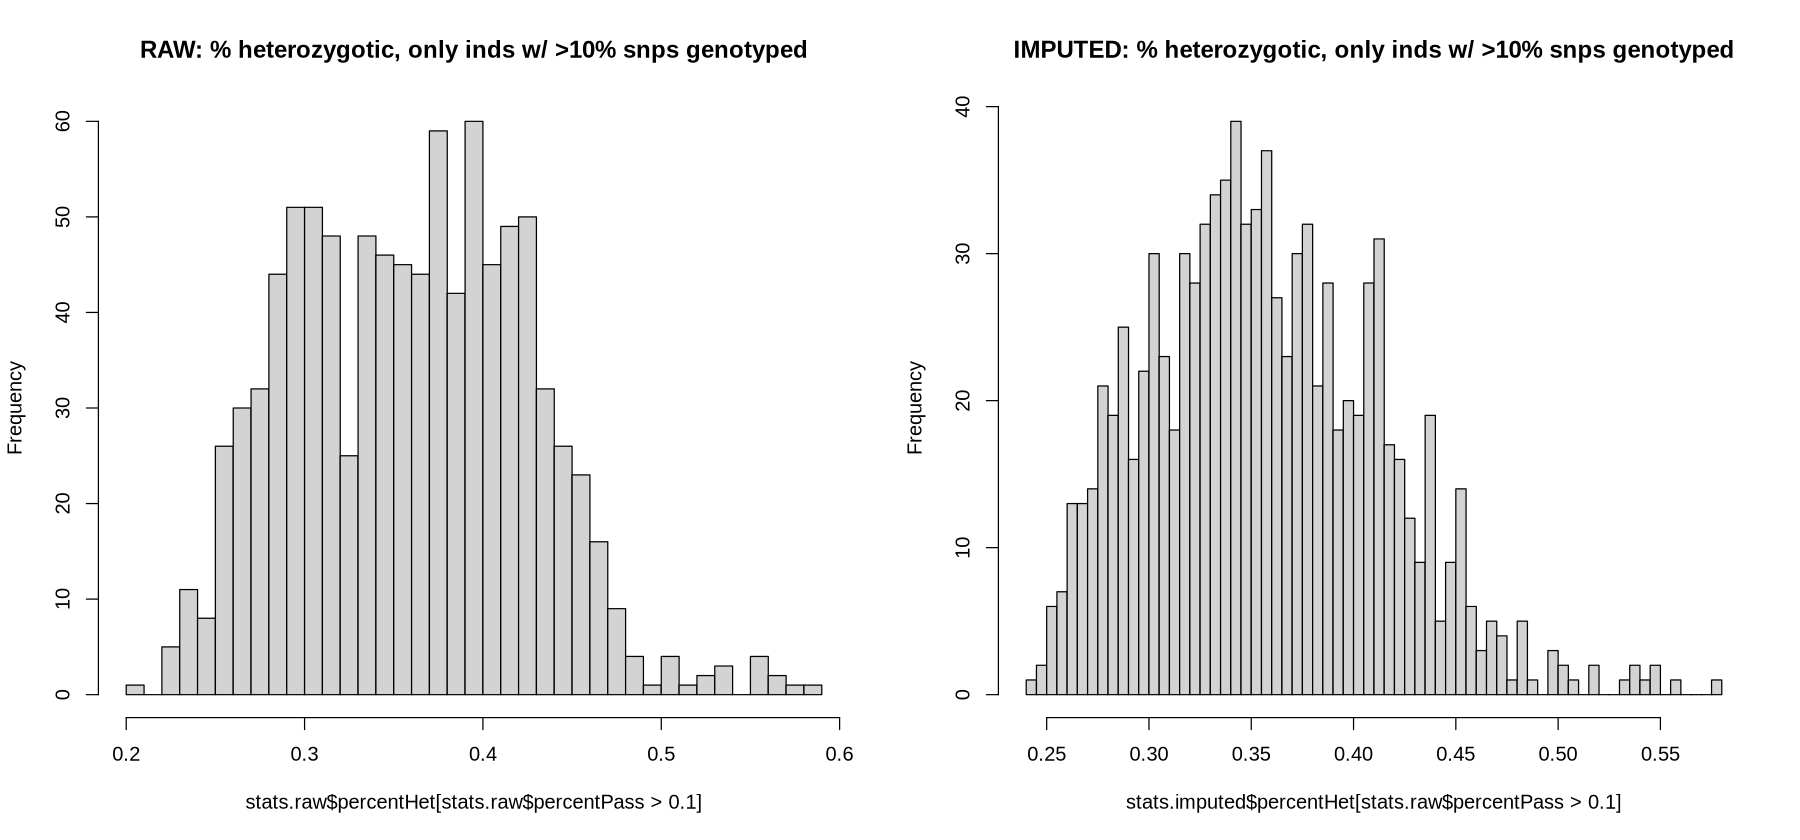

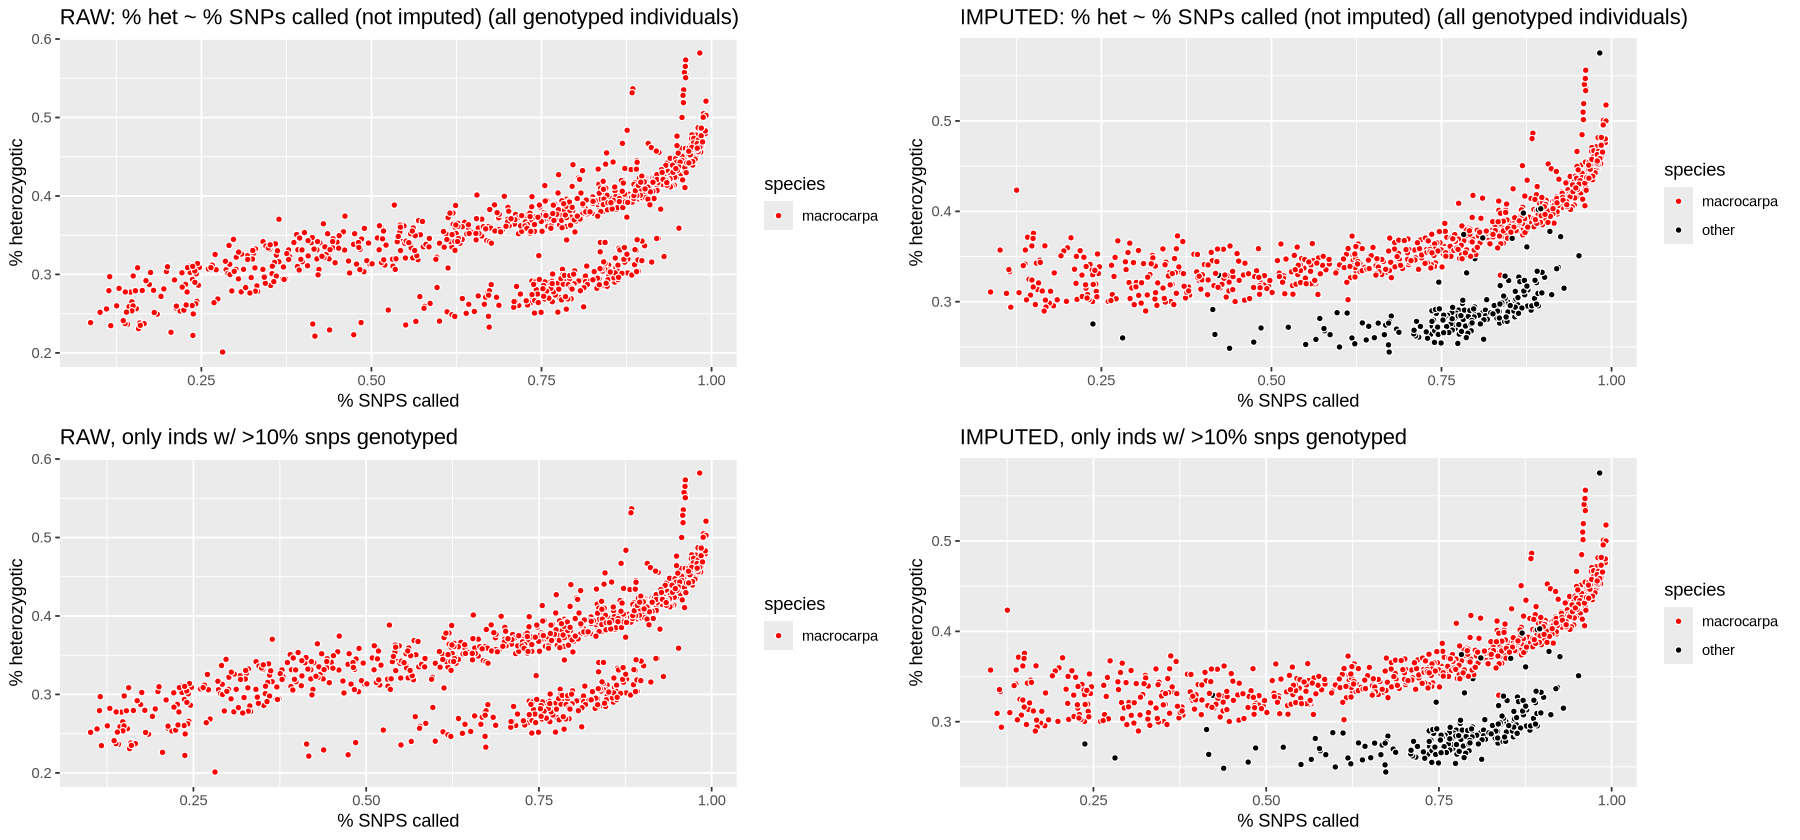

In [3]:
# and plot
options(repr.plot.width = 15, repr.plot.height = 7)
library(ggplot2)
library(gridExtra)

layout(matrix(1:2, 1))
stats.raw$percentPass |> sort() |> barplot(main = "RAW: Percent SNPs called (all genotyped individuals)")

layout(matrix(1:2, 1))
hist(stats.raw$percentHet[stats.raw$percentPass > 0.1],50, main = "RAW: % heterozygotic, only inds w/ >10% snps genotyped")
hist(stats.imputed$percentHet[stats.raw$percentPass > 0.1],50, main = "IMPUTED: % heterozygotic, only inds w/ >10% snps genotyped")

stats.raw$species <- 'macrocarpa'
stats.raw$species[grep('macrocarpa', stats.raw$Qsp, invert = T)] <- 'other'
stats.imputed$species <- 'macrocarpa'
stats.imputed$species[grep('macrocarpa', stats.imputed$Qsp, invert = T)] <- 'other'
stats.imputed$rawpercentpass <- stats.raw$percentPass

p1 <- ggplot(data = stats.raw, aes(x = percentPass, y = percentHet, fill = species)) + 
        geom_point(pch = 21, color = 'white') + scale_fill_manual(values = c(macrocarpa = 'red', other = 'black')) + 
        labs(x = "% SNPS called", 
             y = "% heterozygotic", 
             title = "RAW: % het ~ % SNPs called (not imputed) (all genotyped individuals)")

p2 <- ggplot(data = stats.imputed, aes(x = rawpercentpass, y = percentHet, fill = species)) + 
        geom_point(pch = 21, color = 'white') + scale_fill_manual(values = c(macrocarpa = 'red', other = 'black')) + 
        labs(x = "% SNPS called", 
             y = "% heterozygotic", 
             title = "IMPUTED: % het ~ % SNPs called (not imputed) (all genotyped individuals)")

p3 <- ggplot(data = stats.raw[stats.raw$percentPass > 0.1, ], aes(x = percentPass, y = percentHet, fill = species)) + 
        geom_point(pch = 21, color = 'white') + scale_fill_manual(values = c(macrocarpa = 'red', other = 'black')) + 
        labs(x = "% SNPS called", 
             y = "% heterozygotic", 
             title = "RAW, only inds w/ >10% snps genotyped")

p4 <- ggplot(data = stats.imputed[stats.raw$percentPass > 0.1, ], aes(x = rawpercentpass, y = percentHet, fill = species)) + 
        geom_point(pch = 21, color = 'white') + scale_fill_manual(values = c(macrocarpa = 'red', other = 'black')) + 
        labs(x = "% SNPS called", 
             y = "% heterozygotic", 
             title = "IMPUTED, only inds w/ >10% snps genotyped")

grid.arrange(p1,p2,p3,p4, nrow = 2)

## Prioritizing reruns
Based on what I see here, I would prioritize reruns to balance the number of offspring per mother across all regions. Let's see how things are looking. First, I need to grab the sample sheet of what we submitted and make sure it's lined up with the data we got back

In [6]:
message('Number of sample names in stats missing from submitted')
setdiff(x=row.names(stats.raw), y=dat.submitted$cleanID) |> length()

message('Number of sample names in submitted missing from stats')
setdiff(y=row.names(stats.raw), x=dat.submitted$cleanID) |> length()

message('checking to make sure that intersection set == stats set... and they do! so no ID mismatch issues')
length(intersect(row.names(stats.raw), dat.submitted$cleanID)) - length(row.names(stats.raw))

Number of sample names in stats missing from submitted



[1] 0

Number of sample names in submitted missing from stats



[1] 250

checking to make sure that intersection set == stats set... and they do! so no ID mismatch issues



[1] 0

Now, some summaries:

In [7]:
dat.meta <- read.csv('../out/oak.metadata.cleaned.csv', row.names = 1)
message("# of mothers / offspring genotyped with >10% of SNPs:")
paste(stats.raw.all$MOTHER[stats.raw.all$percentPass > 0.1] |> unique() |> length(), '/',
      sum(!is.na(stats.raw.all$MOTHER[stats.raw.all$percentPass > 0.1]))
      )

message("# of mothers / offspring with some genotype:")
paste(stats.raw.all$MOTHER |> unique() |> length(), '/', 
      sum(!is.na(stats.raw.all$MOTHER))
     )

message("# of mothers / offspring submitted for sequencing:")
paste(dat.meta[dat.submitted$cleanID, 'MOTHER'] |> unique() |> length(), '/',
      sum(!is.na(dat.meta[dat.submitted$cleanID, 'MOTHER']))
      )

message("Proportion of undergenotyped offspring per mother:")
tab.allSent <- table(dat.meta[dat.submitted$cleanID, 'MOTHER'])
index <- names(tab.allSent)
tab.m10 <- table(stats.raw.all$MOTHER[stats.raw.all$percentPass > 0.1])[index]
names(tab.m10) <- index
tab.m10[is.na(tab.m10)] <- 0
tab.propComplete <- round(tab.m10[index] / tab.allSent, 2)
sort(tab.propComplete)

whichsets <- c(.8, .7, .6, .5)
which.do <- how.many.needed <- how.many.to.do <- 
    vector('list', 4) |> structure(names = paste('t', whichsets, sep = '')) 

for(i in whichsets) {   
    index <- paste('t', i, sep = '')
    which.do[[index]] <- 
        which(tab.propComplete < i)
    how.many.needed[[index]] <- 
        ceiling(tab.allSent[which.do[[index]] ] * i)
    how.many.to.do[[index]] <- 
        how.many.needed[[index]] - tab.m10[which.do[[index]]]
    message(
        paste("number needed to bring all mothers up to", i*100, "% completion:", 
              sum(how.many.to.do[[index]])) # close paste
    ) # close message
} # close i

# 70% completion individuals to request
redoset <- how.many.to.do[['t0.7']]
redomat <- stats.raw.all[F, ]

for(i in names(redoset)) {
    # message(paste('doing',i))
    temp <- stats.raw.all[which(stats.raw.all$MOTHER == i & stats.raw.all$percentPass < 0.1), ]
    if(dim(temp)[1] > 1) temp <- temp[order(temp$percentPass, decreasing = TRUE), ]
    redomat <- rbind(redomat, temp[1:redoset[i], ])
} # close i

# head(redoset)
# stop('LEFT OFF HERE')

hist(redomat$percentPass, 20)
write.csv(redomat[order(row.names(redomat)), ], '../out/khufuRedoStats_2024-10-18.csv')
writeLines(sort(row.names(redomat)), '../out/khufuRedoIndividuals_2024-10-18.txt')

## and write out a file that we'll use to subset SNPs for admixture (currently run in an earlier script) --- 
##   also includes two Q. gambelii individuals 
write.table(replicate(c('OAK.MOR.000635', 'OAK.MOR.000132', row.names(stats.raw)[stats.raw$percentPass < 0.1]), n=2), 
            '../data/excludeLowSnps.txt', 
            quote = F, row.names = F, col.names = F) 

# of mothers / offspring genotyped with >10% of SNPs:



[1] "128 / 718"

# of mothers / offspring with some genotype:



[1] "135 / 964"

# of mothers / offspring submitted for sequencing:



[1] "135 / 964"

Proportion of undergenotyped offspring per mother:



 MN_CDR_94    OK_CA_2   OK_EP_12    OK_LP_1   OK_MSP_1    OK_SP_1   OK_SP_10 
      0.00       0.00       0.00       0.00       0.00       0.00       0.00 
 OK_DRA_22   MN_MRV_3   OK_WOO_7  OK_MON_17  IL_LW_637  MN_COO_18  IL_LW_653 
      0.25       0.33       0.38       0.40       0.43       0.44       0.50 
  IL_MOR_1 IL_SN_2411    OK_BS_1  OK_EDW_15   OK_MON_6   OK_SP_12    OK_SP_9 
      0.50       0.50       0.50       0.50       0.50       0.50       0.50 
  OK_WAC_1   OK_WOO_4 IL_SN_2414  MN_CDR_28   MN_CAR_8  IL_BFP_13  IL_MOR_26 
      0.50       0.50       0.55       0.56       0.57       0.60       0.60 
 IL_MOR_27  MN_CDR_35  MN_CRO_14  MN_GEO_49  MN_RSP_94  OK_DRA_21  OK_DRA_23 
      0.60       0.60       0.60       0.60       0.60       0.60       0.60 
 OK_OLI_20   OK_WOO_2   IL_DFP_6  IL_GFP_19  MN_BUN_53  MN_CDR_84  MN_CRO_15 
      0.60       0.60       0.62       0.62       0.62       0.67       0.67 
MN_DAV_100  MN_GEO_51 OK_BLK_121  OK_EDW_10  OK_EDW_16  OK_MON_1

number needed to bring all mothers up to 80 % completion: 123

number needed to bring all mothers up to 70 % completion: 67

number needed to bring all mothers up to 60 % completion: 32

number needed to bring all mothers up to 50 % completion: 15

Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”


ERROR: Error in hist.default(redomat$percentPass, 20): character(0)


## write summary stats for sampling

In [21]:
names(stats.raw.all)
stats.temp <- stats.raw.all
# head(stats.temp)
message('garden individuals submitted by state')
table(stats.raw.all[!is.na(stats.raw.all$MOTHER), 'stateAbb'])
message('garden individuals genotyped by state')
table(stats.temp[!is.na(stats.raw.all$MOTHER) & !is.na(stats.raw.all$percentPass), 'stateAbb'])

message('wild individuals submitted by species')
table(stats.raw.all[is.na(stats.raw.all$MOTHER), 'Qsp'])
message('wild individuals genotyped by species')
table(stats.raw.all[is.na(stats.raw.all$MOTHER) & !is.na(stats.raw.all$percentPass), 'Qsp'])

[1] "id"                 "sample"             "numGenotypesPass"  
 [4] "numGenotypesNonref" "numHomoRef"         "numHomoAlt"        
 [7] "numHet"             "numHemi"            "numSNVs"           
[10] "numIndels"          "numSingletons"      "numMissing"        
[13] "num_ts"             "num_tv"             "ts_tv"             
[16] "percentPass"        "percentHet"         "SPMCODE"           
[19] "Qsp"                "stateAbb"           "MOTHER"

garden individuals submitted by state




 IL  MN  OK 
366 368 230 

garden individuals genotyped by state




 IL  MN  OK 
289 287 143 

wild individuals submitted by species




         alba       bicolor      gambelii        lyrata    macrocarpa 
           57            25             2            15            37 
    michauxii       montana muehlenbergii       sinuata      stellata 
           12             7            50             4            27 

wild individuals genotyped by species




         alba       bicolor      gambelii        lyrata    macrocarpa 
           53            25             2            15            37 
    michauxii       montana muehlenbergii       sinuata      stellata 
           12             7            49             4            27 